# Part 3: Wine-Tasting Machine.

## Step 3.1: Data Preparation

In [54]:
%matplotlib inline


In [5]:
import pandas as pd
from ydata_profiling import ProfileReport

# Load red wine data
red_wine = pd.read_csv("./red_wine.csv")

# Generate a profile report
profile = ProfileReport(red_wine, title="Red Wine Data Report")
profile.to_file("Red_Wine_Data_Profile.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Step 3.2: Model Training and Evaluation

### Step 3.2.1: Define Models and Perform Cross-Validation

In [13]:
# Import Necessary Libraries
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [42]:
# Prepare Data for Training
# Define features and target
X = red_wine.drop(columns=['type'])  # Replace 'quality' with the actual target column name
y = red_wine['type']  # Replace 'quality' with the actual target column name


In [44]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
lr_accuracy = cross_val_score(model_lr, X, y, cv=10, scoring='accuracy').mean()
lr_auc = cross_val_score(model_lr, X, y, cv=10, scoring='roc_auc').mean()


In [19]:
# Naive Bayes
model_nb = GaussianNB()
nb_accuracy = cross_val_score(model_nb, X, y, cv=10, scoring='accuracy').mean()
nb_auc = cross_val_score(model_nb, X, y, cv=10, scoring='roc_auc').mean()


In [33]:
# Decision Tree
model_dt = DecisionTreeClassifier()
dt_accuracy = cross_val_score(model_dt, X, y, cv=10, scoring='accuracy').mean()
dt_auc = cross_val_score(model_dt, X, y, cv=10, scoring='roc_auc').mean()

In [35]:
# SVM (Linear)
model_svm_linear = SVC(kernel='linear', probability=True)
svm_linear_accuracy = cross_val_score(model_svm_linear, X, y, cv=10, scoring='accuracy').mean()
svm_linear_auc = cross_val_score(model_svm_linear, X, y, cv=10, scoring='roc_auc').mean()


In [23]:
# SVM (RBF)
model_svm_rbf = SVC(kernel='rbf', probability=True)
svm_rbf_accuracy = cross_val_score(model_svm_rbf, X, y, cv=10, scoring='accuracy').mean()
svm_rbf_auc = cross_val_score(model_svm_rbf, X, y, cv=10, scoring='roc_auc').mean()


In [25]:
# Random Forest
model_rf = RandomForestClassifier()
rf_accuracy = cross_val_score(model_rf, X, y, cv=10, scoring='accuracy').mean()
rf_auc = cross_val_score(model_rf, X, y, cv=10, scoring='roc_auc').mean()


#### Print the Results

In [37]:
print(f"Logistic Regression - Accuracy: {lr_accuracy}, AUC: {lr_auc}")
print(f"Naive Bayes - Accuracy: {nb_accuracy}, AUC: {nb_auc}")
print(f"Decision Tree - Accuracy: {dt_accuracy}, AUC: {dt_auc}")
print(f"SVM (Linear) - Accuracy: {svm_linear_accuracy}, AUC: {svm_linear_auc}")
print(f"SVM (RBF) - Accuracy: {svm_rbf_accuracy}, AUC: {svm_rbf_auc}")
print(f"Random Forest - Accuracy: {rf_accuracy}, AUC: {rf_auc}")


Logistic Regression - Accuracy: 0.7847852389594676, AUC: 0.8799019697944429
Naive Bayes - Accuracy: 0.8216273442226255, AUC: 0.8954078975584352
Decision Tree - Accuracy: 0.7532667876588022, AUC: 0.7546388199614007
SVM (Linear) - Accuracy: 0.7918632788868724, AUC: 0.8814885274025059
SVM (RBF) - Accuracy: 0.5358439201451907, AUC: 0.8689201360169102
Random Forest - Accuracy: 0.8039927404718693, AUC: 0.8894087553227339


### Step 3.3: Plot the ROC Curve for Random Forest

In [48]:
# Convert 'high' and 'low' labels to binary values
y = y.map({'high': 1, 'low': 0})

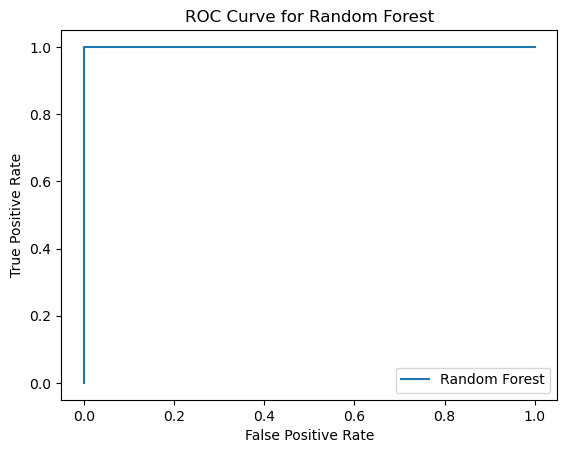

<Figure size 640x480 with 0 Axes>

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Fit Random Forest on the whole dataset
model_rf.fit(X, y)
y_pred_proba = model_rf.predict_proba(X)[:, 1]

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y, y_pred_proba, pos_label=1)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend()
plt.show()

# Save as an image
plt.savefig('roc_curve_random_forest.png')


### Step 3.4: Evaluate on White Wine Data

In [65]:
# Load white wine data
white_wine = pd.read_csv("./white_Wine.csv")
X_white = white_wine.drop(columns=['type'])  # Replace 'quality' with the actual target column name
y_white = white_wine['type']  # Replace 'quality' with the actual target column name

# Evaluate the best model (e.g., Random Forest) on white wine data
white_auc = cross_val_score(model_nb, X_white, y_white, cv=10, scoring='roc_auc').mean()
print("AUC on White Wine Data:", white_auc)

AUC on White Wine Data: 0.95
